In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(768, 7)

Column names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

Data types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

Missing values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [4]:
# Remove rows with missing values
df = df.dropna()

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nNew shape of dataset:")
print(df.shape)

Missing values after cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

New shape of dataset:
(740, 7)


In [6]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check the column names
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


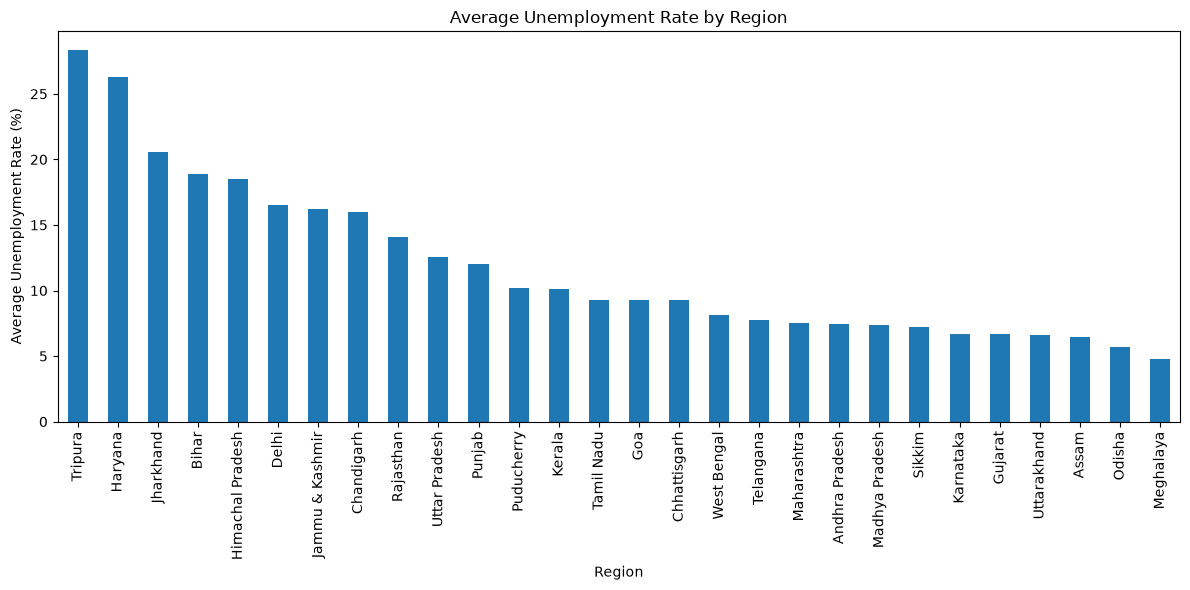

In [7]:
import matplotlib.pyplot as plt

average_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

average_unemployment.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

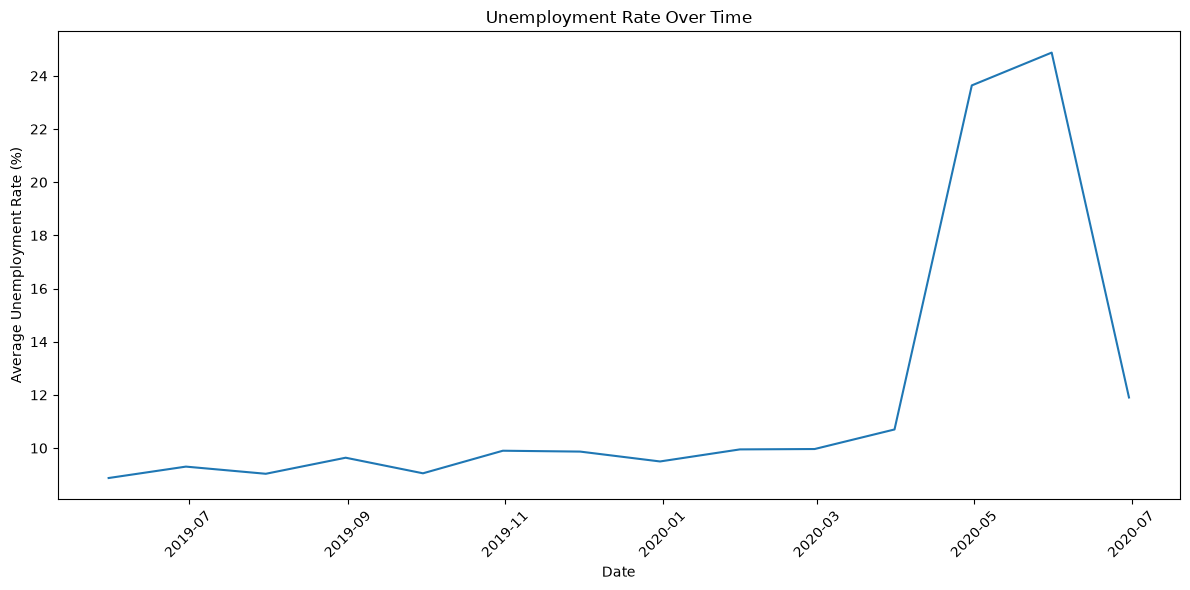

In [8]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Calculate average unemployment rate by date
monthly_unemployment = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

# Create line graph
plt.figure(figsize=(12, 6))
plt.plot(monthly_unemployment.index, monthly_unemployment.values)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

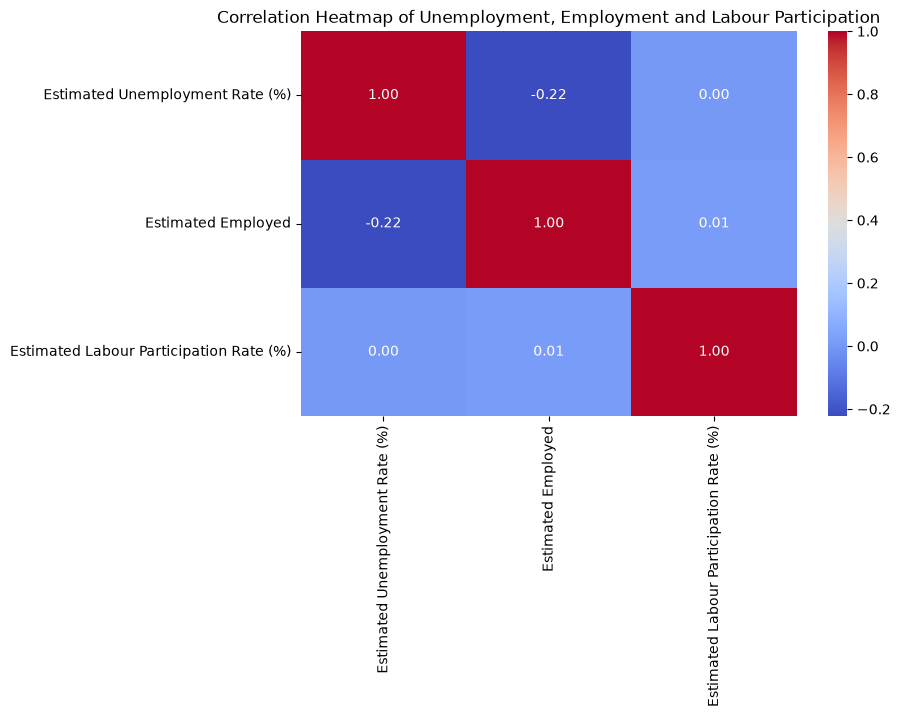

In [9]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
correlation = df[
    ['Estimated Unemployment Rate (%)',
     'Estimated Employed',
     'Estimated Labour Participation Rate (%)']
].corr()

# Create heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Unemployment, Employment and Labour Participation')
plt.show()